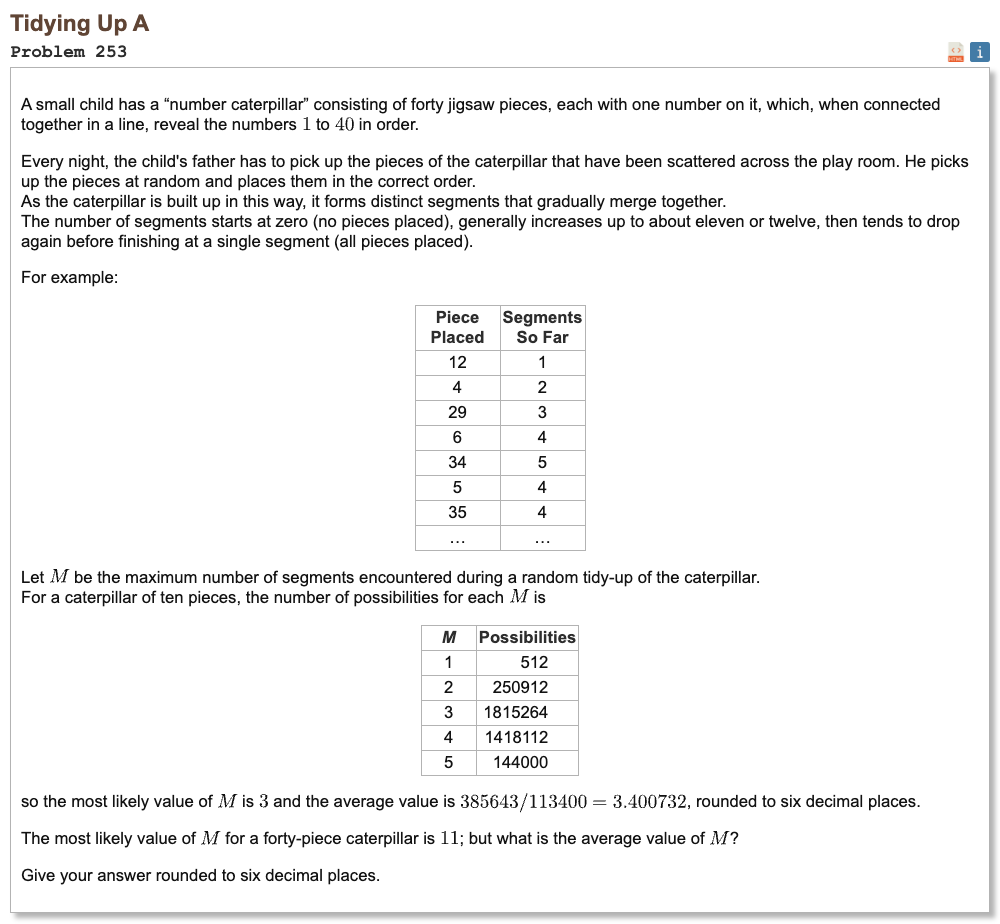

## Initial approach

* think of the current layout as k separate consecutive blocks (segments) of already placed pieces
* when you place one new piece, it either starts a new segment, extends an existing segment, or merges two segments into one
* for a line, the number of “places you can extend”, “places you can start”, and “places you can merge” depends only on k and whether the two ends (1 and n) are already occupied
* use a dynamic program over steps i, current segments k, max segments so far m, and two end flags (left end filled, right end filled)
* update counts for all possible next moves, and carry forward the new current k and updated max m
* after n placements, only states with one segment and both ends filled are complete, average their recorded max values
* output the average rounded to 6 decimals

In [1]:
def solve():
    n = 40
    N = n + 3

    f = [[[[[0.0 for _ in range(2)] for _ in range(2)] for _ in range(N)] for _ in range(N)] for _ in range(N)]

    f[1][1][1][0][1] = 1.0
    f[1][1][1][0][0] = 1.0
    f[1][1][1][1][0] = 1.0

    for i in range(1, n):
        for m in range(1, n + 1):
            for k in range(0, n + 1):
                for left_end in range(2):
                    for right_end in range(2):
                        v = f[i][m][k][left_end][right_end]
                        if v == 0.0:
                            continue
                        if k == 1 and left_end == 1 and right_end == 1:
                            continue

                        nk = k - 1

                        if left_end == 0:
                            if k > 0:
                                f[i + 1][m][k][1][right_end] += v
                                f[i + 1][m][k][0][right_end] += v
                            mm = m if m >= k + 1 else (k + 1)
                            f[i + 1][mm][k + 1][1][right_end] += v
                            f[i + 1][mm][k + 1][0][right_end] += v

                        if right_end == 0:
                            if k > 0:
                                f[i + 1][m][k][left_end][1] += v
                                f[i + 1][m][k][left_end][0] += v
                            mm = m if m >= k + 1 else (k + 1)
                            f[i + 1][mm][k + 1][left_end][1] += v
                            f[i + 1][mm][k + 1][left_end][0] += v

                        if k > 1:
                            f[i + 1][m][k - 1][left_end][right_end] += nk * v
                        if k > 0:
                            f[i + 1][m][k][left_end][right_end] += nk * 2.0 * v
                        mm = m if m >= k + 1 else (k + 1)
                        f[i + 1][mm][k + 1][left_end][right_end] += nk * v

    num = 0.0
    den = 0.0
    for m in range(1, n + 1):
        v = f[n][m][1][1][1]
        if v != 0.0:
            num += m * v
            den += v

    result = num / den
    print("Result:", f"{result:.6f}")

In [2]:
%%time
solve()

Result: 11.492847
CPU times: user 84.6 ms, sys: 5.24 ms, total: 89.8 ms
Wall time: 88.9 ms
